In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
conn = sqlite3.connect("sales_analyze.db")

# Monthly Revenue Trend (Line Chart)

In [2]:
query= """
SELECT strftime('%Y-%m',Date) as Month, sum(total_amount) as MonthlyRevenue 
From cleaned_sales 
GROUP BY Month 
ORDER BY Month;
"""
df = pd.read_sql_query(query, conn)


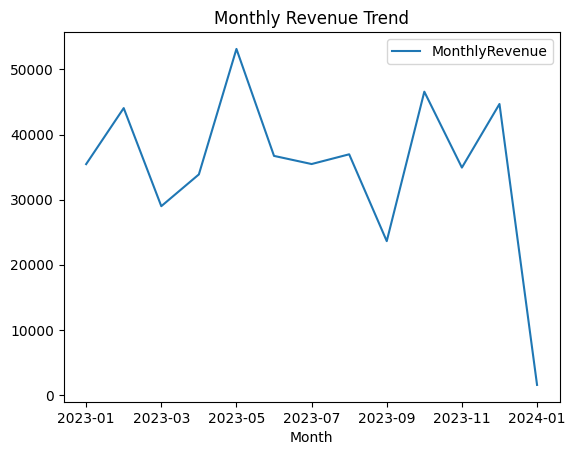

In [3]:
df.plot(kind="line", x="Month", y="MonthlyRevenue")
plt.title("Monthly Revenue Trend")
plt.show()

# Revenue by Gender (Pie Chart)

In [4]:
query = "SELECT gender, sum(total_amount) as TotalRevenue FROM cleaned_sales GROUP BY gender;"
df_gender = pd.read_sql_query(query,conn)

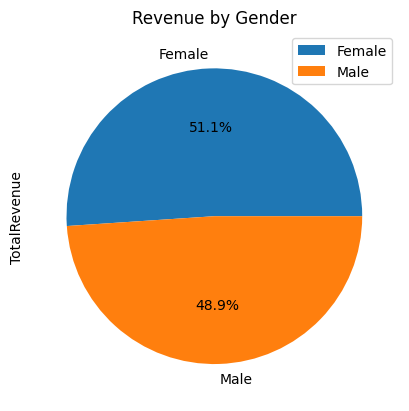

In [5]:
df_gender.plot(kind="pie", y="TotalRevenue", labels=df_gender["gender"], autopct="%1.1f%%")
plt.title("Revenue by Gender")
plt.show()

# Revenue by Product Category (Bar Chart)

In [6]:
query = "SELECT product_category, sum(total_amount) as TotalRevenue FROM cleaned_sales GROUP BY product_category;"
df_category = pd.read_sql_query(query,conn)

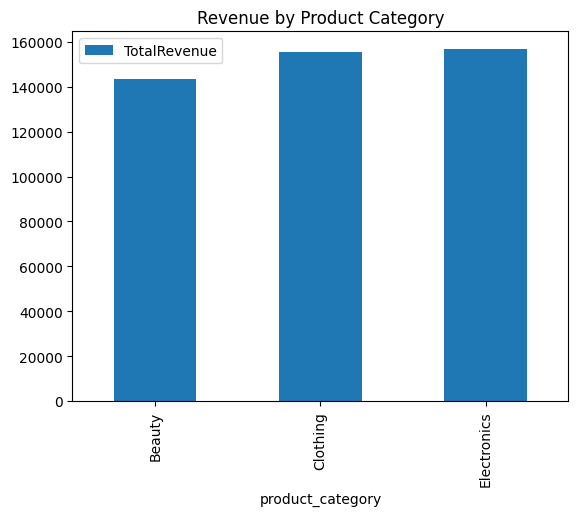

In [7]:
df_category.plot(kind="bar", x="product_category", y="TotalRevenue")
plt.title("Revenue by Product Category")
plt.show()

# Revenue by Age Group (Histogram/Bar Chart)

In [8]:
query = """SELECT CASE
	WHEN age BETWEEN 18 AND 25 THEN '18-25'
	WHEN age BETWEEN 26 AND 35 THEN '26-35'
	WHEN age BETWEEN 36 AND 50 THEN '36-50'
	ELSE '50+'
END as AgeGroup,
sum(total_amount) as Revenue
FROM cleaned_sales
GROUP BY AgeGroup
ORDER BY Revenue DESC;"""
df_age = pd.read_sql_query(query,conn)

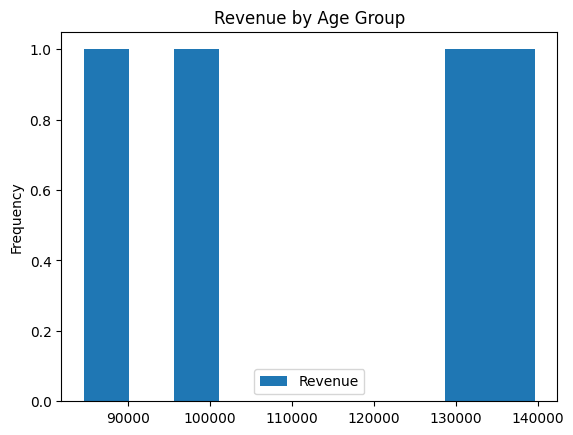

In [9]:
df_age.plot(kind="hist", x="AgeGroup", y="Revenue")
plt.title("Revenue by Age Group")
plt.show()

# Average Order Value per Month (Line Chart)

In [10]:
query = "SELECT strftime('%Y-%m',Date) as Month, avg(total_amount) as AvgOrderValue FROM cleaned_sales GROUP BY Month ORDER BY Month;"
df_month = pd.read_sql_query(query,conn)

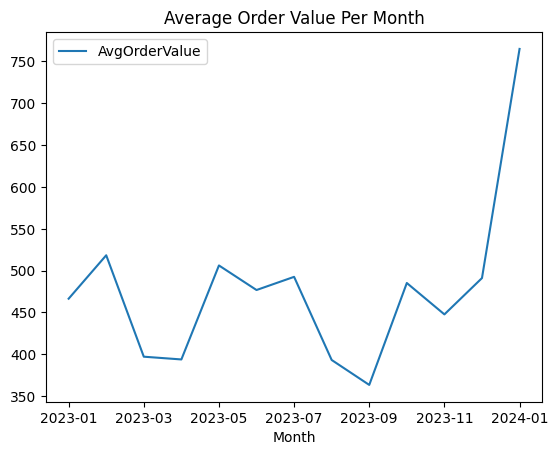

In [11]:
df_month.plot(kind="line", x="Month", y="AvgOrderValue")
plt.title("Average Order Value Per Month")
plt.show()

# Most Popular Product Category by Quantity (Bar Chart)

In [12]:
query = "SELECT product_category, sum(quantity) as TotalUnits FROM cleaned_sales GROUP BY product_category ORDER BY TotalUnits DESC LIMIT 1; "
df_quantity = pd.read_sql_query(query,conn)

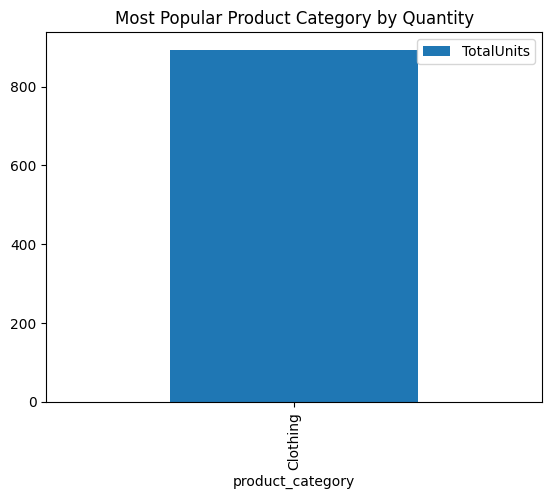

In [13]:
df_quantity.plot(kind="bar", x="product_category", y="TotalUnits")
plt.title("Most Popular Product Category by Quantity")
plt.show()